In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2
import folium

In [ ]:
df1 = pd.read_csv('posizioni_stazioni.csv', sep=',', encoding='UTF-8')

In [ ]:
df1

In [ ]:
df2 = pd.read_csv('openmeteo_posizioni_stazioni.csv', sep=',', encoding='UTF-8')

In [ ]:
df2

# Studio differenze tra le stazioni originali e quelle offerte da open-meteo

1. Boxplot distanza

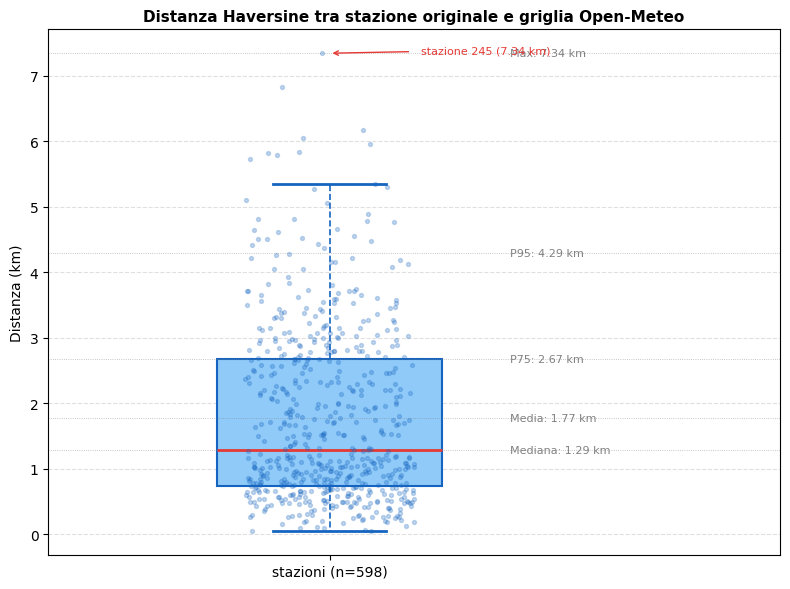

In [4]:
# --- Haversine ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# --- Dati ---
orig = pd.read_csv("posizioni_stazioni.csv")
om   = pd.read_csv("openmeteo_posizioni_stazioni.csv")

df = orig.merge(om, on="station_id")
df["dist_km"] = df.apply(
    lambda r: haversine(r["station_lat"], r["station_lon"], r["stat_lat"], r["stat_lon"]),
    axis=1
)

# --- Grafico ---
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    df["dist_km"],
    vert=True,
    patch_artist=True,
    widths=0.4,
    boxprops=dict(facecolor="#90CAF9", color="#1565C0", linewidth=1.5),
    medianprops=dict(color="#E53935", linewidth=2),
    whiskerprops=dict(color="#1565C0", linewidth=1.2, linestyle="--"),
    capprops=dict(color="#1565C0", linewidth=2),
    flierprops=dict(marker="o", color="#FF7043", alpha=0.5, markersize=4, markeredgewidth=0),
)

# Jitter dei punti sovrapposto
x_jitter = np.random.uniform(-0.15, 0.15, size=len(df))
ax.scatter(1 + x_jitter, df["dist_km"], alpha=0.25, s=8, color="#1565C0", zorder=3)

# Annotazioni statistiche
stats = {
    "Mediana": df["dist_km"].median(),
    "Media":   df["dist_km"].mean(),
    "P75":     df["dist_km"].quantile(0.75),
    "P95":     df["dist_km"].quantile(0.95),
    "Max":     df["dist_km"].max(),
}
for label, val in stats.items():
    ax.axhline(val, color="gray", linewidth=0.6, linestyle=":", alpha=0.6)
    ax.text(1.32, val, f"{label}: {val:.2f} km", va="center", fontsize=8, color="gray")

# Stazione con distanza massima
idx_max = df["dist_km"].idxmax()
ax.annotate(
    f"  stazione {df.loc[idx_max, 'station_id']} ({df.loc[idx_max, 'dist_km']:.2f} km)",
    xy=(1, df.loc[idx_max, "dist_km"]),
    xytext=(1.15, df.loc[idx_max, "dist_km"]),
    fontsize=8, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1),
)

ax.set_title("Distanza Haversine tra stazione originale e griglia Open-Meteo", fontsize=11, fontweight="bold")
ax.set_ylabel("Distanza (km)", fontsize=10)
ax.set_xticks([1])
ax.set_xticklabels(["stazioni (n=598)"])
ax.set_xlim(0.5, 1.8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
# plt.savefig("boxplot_distanza_km.png", dpi=150, bbox_inches="tight")
plt.show()

2. Calcolo media, dev. standard, ecc...

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raggio Terra in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df["dist_km"] = df.apply(
    lambda r: haversine(r["station_lat"], r["station_lon"], r["stat_lat"], r["stat_lon"]),
    axis=1
)

print(df["dist_km"].describe().round(3))
print(f"\nMax distanza: {df['dist_km'].max():.2f} km  →  stazione {df.loc[df['dist_km'].idxmax(), 'station_id']}")

count    598.000
mean       1.768
std        1.315
min        0.041
25%        0.731
50%        1.286
75%        2.673
max        7.341
Name: dist_km, dtype: float64

Max distanza: 7.34 km  →  stazione 245


# Scelta di stazioni outlier oltre il 98esimo percentile (5.25 km)

In [ ]:
soglia = df["dist_km"].quantile(0.98)  # 5,2 km

outlier = df[df["dist_km"] > soglia][["station_id", "station_lat", "station_lon",
                                       "stat_lat", "stat_lon", "dist_km"]].sort_values("dist_km", ascending=False)
print(outlier.to_string())
print(len(outlier))

     station_id  station_lat  station_lon  stat_lat  stat_lon   dist_km
245         245    41.665280    15.945000   41.6250   15.8750  7.341168
569         569    38.174341    15.546512   38.1250   15.5000  6.829589
105         105    42.572591    12.962063   42.6250   12.9375  6.164683
349         349    37.977911    13.687987   38.0000   13.6250  6.041726
524         524    37.075693    14.223844   37.1250   14.2500  5.953222
505         505    42.421390    14.279170   42.3750   14.3125  5.839431
315         315    38.198256    15.552935   38.2500   15.5625  5.814022
247         247    41.113611    16.888056   41.0625   16.8750  5.787657
554         554    42.073612    11.815903   42.1250   11.8125  5.720978
532         532    40.760600    14.438150   40.7500   14.5000  5.341337
54           54    37.070349    14.253618   37.0625   14.3125  5.296797
576         576    40.470590    15.298730   40.5000   15.2500  5.261050
12


In [19]:
outlier_list = [245, 569, 105, 349, 524, 505, 315, 247, 554, 532, 54, 576]

Visualizzazione su mappa delle stazioni outlier

In [ ]:
# --- Haversine ---
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# --- Dati ---
orig = pd.read_csv("posizioni_stazioni.csv")
om   = pd.read_csv("openmeteo_posizioni_stazioni.csv")

df = orig.merge(om, on="station_id")
df["dist_km"] = df.apply(
    lambda r: haversine(r["station_lat"], r["station_lon"], r["stat_lat"], r["stat_lon"]),
    axis=1
)

soglia = df["dist_km"].quantile(0.98)
outlier = df[df["dist_km"] > soglia].copy()

# --- Colori per fascia di distanza ---
def dist_color(d):
    if d >= 6.5: return "#E24B4A"
    if d >= 5.5: return "#EF9F27"
    if d >= 4.5: return "#378ADD"
    return "#1D9E75"

def dist_radius(d):
    return 5 + (d - 3.5) * 1.6

# --- Mappa ---
m = folium.Map(location=[41.5, 13.5], zoom_start=6, tiles="OpenStreetMap")

for _, r in outlier.iterrows():
    col = dist_color(r["dist_km"])
    rad = dist_radius(r["dist_km"])

    # Cerchio sulla stazione originale
    folium.CircleMarker(
        location=[r["station_lat"], r["station_lon"]],
        radius=rad,
        color="white",
        weight=1.5,
        fill=True,
        fill_color=col,
        fill_opacity=0.85,
        popup=folium.Popup(
            f"""<b>Stazione {int(r['station_id'])}</b><br>
            <span style='color:#555;font-size:12px;'>originale:</span>
            {r['station_lat']:.4f}, {r['station_lon']:.4f}<br>
            <span style='color:#555;font-size:12px;'>Open-Meteo:</span>
            {r['stat_lat']:.4f}, {r['stat_lon']:.4f}<br>
            <span style='font-weight:600;color:{col};'>
            distanza: {r['dist_km']:.2f} km</span>""",
            max_width=220
        )
    ).add_to(m)

    # Linea tratteggiata verso il punto Open-Meteo
    folium.PolyLine(
        locations=[[r["station_lat"], r["station_lon"]],
                   [r["stat_lat"],    r["stat_lon"]]],
        color=col, weight=1.5, opacity=0.5, dash_array="6"
    ).add_to(m)

# --- Legenda ---
legend_html = """
<div style="position:fixed;bottom:30px;right:10px;z-index:1000;
            background:white;padding:10px 14px;border-radius:8px;
            font-size:12px;line-height:1.9;border:1px solid #ccc;">
  <b>distanza (km)</b><br>
  <span style='color:#1D9E75;font-size:16px;'>●</span> 3.5 – 4.5<br>
  <span style='color:#378ADD;font-size:16px;'>●</span> 4.5 – 5.5<br>
  <span style='color:#EF9F27;font-size:16px;'>●</span> 5.5 – 6.5<br>
  <span style='color:#E24B4A;font-size:16px;'>●</span> &gt; 6.5
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# m.save("mappa_outlier_stazioni.html")
print(f"Soglia P90: {soglia:.3f} km  |  Stazioni outlier: {len(outlier)}")
m  # mostra la mappa inline nel notebook

Soglia P90: 5.109 km  |  Stazioni outlier: 12


# Eliminazione stazioni outlier e merge

In [3]:
df1 = pd.read_csv('dati_tesi_completi6.csv', sep=',', encoding='UTF-8')

In [5]:
df2 = pd.read_csv('posizioni_stazioni.csv', sep=',', encoding='UTF-8')

In [11]:
df3 = pd.read_csv('open-meteo-totale.csv', sep=',', encoding='UTF-8')

In [ ]:
cols = ['station_lat', 'station_lon', 'station_altitude']

df1 = pd.merge(
    df1,
    df2,
    on=cols,
    how='left'
)

In [8]:
df1

,region_name,municipality_name,station_municipality,station_name,station_eu_code,station_position,station_lat,station_lon,station_altitude,primary_observation_notation,data_record_start_time,data_record_end_time,data_record_value,observation_unit_notation,pollutant_notation,pollutant_label,station_id
0,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,0 days 01:00:00,2025-01-01 01:00:00,2025-01-01 02:00:00,200.0,µg/m3,CO,Carbon monoxide (air),0
1,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,0 days 01:00:00,2025-01-01 04:00:00,2025-01-01 05:00:00,300.0,µg/m3,CO,Carbon monoxide (air),0
2,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,0 days 01:00:00,2025-01-01 17:00:00,2025-01-01 18:00:00,200.0,µg/m3,CO,Carbon monoxide (air),0
3,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,0 days 01:00:00,2025-01-01 22:00:00,2025-01-01 23:00:00,300.0,µg/m3,CO,Carbon monoxide (air),0
4,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,0 days 01:00:00,2025-01-01 23:00:00,2025-01-02 00:00:00,200.0,µg/m3,CO,Carbon monoxide (air),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5397986,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,0 days 01:00:00,2025-12-30 02:00:00,2025-12-30 03:00:00,13.0,µg/m3,O3,Ozone (air),597
5397987,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,0 days 01:00:00,2025-12-30 07:00:00,2025-12-30 08:00:00,10.4,µg/m3,O3,Ozone (air),597
5397988,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,0 days 01:00:00,2025-12-30 09:00:00,2025-12-30 10:00:00,55.6,µg/m3,O3,Ozone (air),597
5397989,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,0 days 01:00:00,2025-12-30 23:00:00,2025-12-31 00:00:00,30.2,µg/m3,O3,Ozone (air),597


In [10]:
df1 = df1[[
    'region_name', 'municipality_name', 'station_municipality', 'station_name', # regione, comune
    'station_eu_code', 'station_id', # codici stazione
    'station_position', 'station_lat', 'station_lon', 'station_altitude', # posizione stazione
    'primary_observation_notation', 'data_record_start_time', 'data_record_end_time', # modo e tempo osservazione
    'data_record_value', 'observation_unit_notation', 'pollutant_notation', 'pollutant_label' # descrizione osservazione 
]].copy()

In [12]:
df1['data_record_start_time'] = pd.to_datetime(df1['data_record_start_time'])
df3['data_record_start_time'] = pd.to_datetime(df3['data_record_start_time'])

In [15]:
cols = ['station_id', 'data_record_start_time']

df1 = pd.merge(
    df1,
    df3,
    on=cols,
    how='left'
)

In [16]:
df1

,region_name,municipality_name,station_municipality,station_name,station_eu_code,station_id,station_position,station_lat,station_lon,station_altitude,...,data_record_end_time,data_record_value,observation_unit_notation,pollutant_notation,pollutant_label,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),wind_speed_10m (km/h),wind_direction_10m (°)
0,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 02:00:00,200.0,µg/m3,CO,Carbon monoxide (air),8.4,86,0.0,7.2,72
1,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 05:00:00,300.0,µg/m3,CO,Carbon monoxide (air),8.6,82,0.0,8.8,81
2,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 18:00:00,200.0,µg/m3,CO,Carbon monoxide (air),12.4,81,0.0,8.6,147
3,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-01 23:00:00,300.0,µg/m3,CO,Carbon monoxide (air),11.0,70,0.0,3.6,135
4,TOSCANA,Piombino,MAGAZZINI COMUNALI - LOC. COTONE - Piombino (LI),LI-COTONE,IT0063A,0,POINT Z (10.534167 42.939167 37),42.939167,10.534167,37.0,...,2025-01-02 00:00:00,200.0,µg/m3,CO,Carbon monoxide (air),10.7,73,0.0,3.3,174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5397986,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 03:00:00,13.0,µg/m3,O3,Ozone (air),0.6,87,0.0,4.3,66
5397987,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 08:00:00,10.4,µg/m3,O3,Ozone (air),-1.2,83,0.0,3.2,117
5397988,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-30 10:00:00,55.6,µg/m3,O3,Ozone (air),3.1,63,0.0,1.5,76
5397989,FRIULI_VENEZIA_GIULIA,Gorizia,via Duca D'Aosta 117 - Gorizia (GO),Gorizia - via Duca D'Aosta 117,IT2324A,597,POINT Z (13.616127 45.936478 79),45.936478,13.616127,79.0,...,2025-12-31 00:00:00,30.2,µg/m3,O3,Ozone (air),0.4,61,0.0,3.8,73


In [21]:
print(outlier_list)

df1 = df1[~df1['station_id'].isin(outlier_list)].reset_index(drop=True)

[245, 569, 105, 349, 524, 505, 315, 247, 554, 532, 54, 576]
Stazioni rimaste: <bound method IndexOpsMixin.value_counts of 0            0
1            0
2            0
3            0
4            0
          ... 
5287851    597
5287852    597
5287853    597
5287854    597
5287855    597
Name: station_id, Length: 5287856, dtype: int64>


In [ ]:
stazioni = (df1['station_eu_code'].value_counts())

print('Le stazioni sono:', len(stazioni), '\n')

"""""
Comuni da 409 a 402
Stazioni da 598 a 586
"""""

Le stazioni sono: 586 



In [24]:
df1.to_csv('dati_tesi_finali.csv', index=False)